# Análise SES natureza

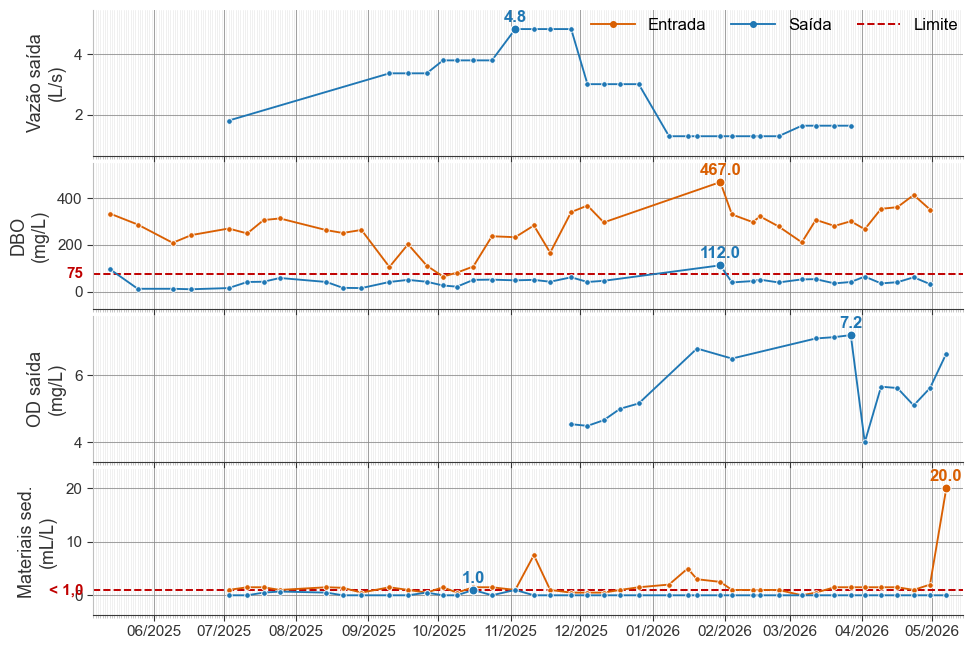

Figura salva em: C:\Users\gabriel.coimbra\Desktop\Concórdia\Análise SES Natureza\mosaico_monitoramento_ete_natureza.png


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path

# ============================================================
# 1. LEITURA E TRATAMENTO DOS DADOS
# ============================================================

arquivo = Path(
    r"C:\Users\gabriel.coimbra\Desktop\Concórdia\Análise SES Natureza\SESNatureza_Monitoramento.xlsx"
)

aba = "Plan1"

df = pd.read_excel(arquivo, sheet_name=aba)

# Conversão da coluna de data
if pd.api.types.is_numeric_dtype(df["data"]):
    df["data"] = pd.to_datetime(
        df["data"],
        origin="1899-12-30",
        unit="D"
    )
else:
    df["data"] = pd.to_datetime(
        df["data"],
        errors="coerce",
        dayfirst=True
    )

# Colunas numéricas utilizadas
colunas_numericas = [
    "vazao_l_s",
    "dbo_mg_l_entrada",
    "dbo_mg_l_saida",
    "od_mg_l_saida",
    "solidos_mg_l_entrada",
    "solidos_mg_l_saida"
]

for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

# Remove datas inválidas e ordena cronologicamente
df = (
    df.dropna(subset=["data"])
      .sort_values("data")
      .reset_index(drop=True)
)


# ============================================================
# 2. CONFIGURAÇÕES VISUAIS
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 13

cor_saida = "#1F77B4"
cor_entrada = "#D95F02"
cor_texto = "#333333"
cor_grid_principal = "#8A8A8A"
cor_grid_secundario = "#CCCCCC"
cor_limite = "#C00000"

# Valores máximos permitidos / critérios aplicáveis ao efluente tratado
limite_dbo = 75.0       # mg/L
limite_ssed = 1.0       # mL/L - critério: inferior a 1,0 mL/L

# ============================================================
# 3. FUNÇÃO PARA PLOTAR AS SÉRIES
# ============================================================

def plotar_serie(
    ax,
    x,
    y,
    cor,
    linestyle="-",
    linewidth=1.35,
    marker="o",
    markersize=4,
    offset_max=(0, 4),
    casas_decimais=1
):
    """
    Plota uma série temporal com marker em todos os registros válidos
    e rótulo apenas no ponto de maior valor.
    """

    dados = pd.DataFrame({
        "data": x,
        "valor": y
    }).dropna()

    if dados.empty:
        return

    # Linha com marker em todos os dados monitorados
    ax.plot(
        dados["data"],
        dados["valor"],
        color=cor,
        linestyle=linestyle,
        linewidth=linewidth,
        marker=marker,
        markersize=markersize,
        markerfacecolor=cor,
        markeredgecolor="white",
        markeredgewidth=0.6,
        zorder=3
    )

    # Identificação do maior valor da série
    indice_max = dados["valor"].idxmax()
    ponto_max = dados.loc[indice_max]

    # Destaque discreto do maior valor
    ax.scatter(
        ponto_max["data"],
        ponto_max["valor"],
        color=cor,
        edgecolor="white",
        linewidth=0.8,
        s=42,
        zorder=4
    )

    # Rótulo somente do maior valor, próximo ao ponto
    ax.annotate(
        f'{ponto_max["valor"]:.{casas_decimais}f}',
        xy=(ponto_max["data"], ponto_max["valor"]),
        xytext=offset_max,
        textcoords="offset points",
        color=cor,
        fontsize=12,
        fontweight="bold",
        ha="center",
        va="bottom",
        zorder=5
    )

# ============================================================
# 3.1. FUNÇÃO PARA INSERIR LINHA DE LIMITE APLICÁVEL
# ============================================================

def adicionar_limite(
    ax,
    valor_limite,
    texto_limite,
    cor=cor_limite,
    linewidth=1.4
):
    """
    Insere linha horizontal tracejada correspondente ao limite aplicável
    ao efluente tratado e identifica o valor junto ao eixo Y.
    """

    ax.axhline(
        y=valor_limite,
        color=cor,
        linestyle="--",
        linewidth=linewidth,
        zorder=2
    )

    ax.annotate(
        texto_limite,
        xy=(0, valor_limite),
        xycoords=("axes fraction", "data"),
        xytext=(-7, 0),
        textcoords="offset points",
        color=cor,
        fontsize=11,
        fontweight="bold",
        ha="right",
        va="center",
        annotation_clip=False,
        zorder=6
    )
    
# ============================================================
# 4. CRIAÇÃO DO MOSAICO
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 7.2),
    sharex=True,
    gridspec_kw={"hspace": 0.05}
)

fig.patch.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("white")

    # Grid principal: meses e eixo Y
    ax.grid(
        True,
        which="major",
        axis="both",
        color=cor_grid_principal,
        linewidth=0.75,
        linestyle="-",
        alpha=0.80,
        zorder=0
    )

    # Grid secundário: dias, mais claro
    ax.grid(
        True,
        which="minor",
        axis="x",
        color=cor_grid_secundario,
        linewidth=0.45,
        linestyle="-",
        alpha=0.45,
        zorder=0
    )

    ax.tick_params(
        axis="both",
        which="major",
        colors=cor_texto,
        length=4,
        labelsize=11
    )

    ax.tick_params(
        axis="x",
        which="minor",
        colors="#BFBFBF",
        length=2
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#BFBFBF")
    ax.spines["bottom"].set_color("#383838")

    ax.margins(x=0.02)

    # Mantém alguma folga para o rótulo do maior valor
    ax.margins(y=0.18)


# ============================================================
# 5. PAINEL 1: VAZÃO DE SAÍDA
# ============================================================

plotar_serie(
    ax=axes[0],
    x=df["data"],
    y=df["vazao_l_s"],
    cor=cor_saida,
    linestyle="-",
    offset_max=(0, 3)
)

axes[0].set_ylabel(
    "Vazão saída\n(L/s)",
    color=cor_texto,
    labelpad=6
)


# ============================================================
# 6. PAINEL 2: DBO DE ENTRADA E SAÍDA
# ============================================================

plotar_serie(
    ax=axes[1],
    x=df["data"],
    y=df["dbo_mg_l_entrada"],
    cor=cor_entrada,
    linestyle="-",
    offset_max=(0, 3)
)

plotar_serie(
    ax=axes[1],
    x=df["data"],
    y=df["dbo_mg_l_saida"],
    cor=cor_saida,
    linestyle="-",
    offset_max=(0, 3)
)

adicionar_limite(
    ax=axes[1],
    valor_limite=limite_dbo,
    texto_limite="75"
)

axes[1].set_ylabel(
    "DBO\n(mg/L)",
    color=cor_texto,
    labelpad=6
)


# ============================================================
# 7. PAINEL 3: OD DE SAÍDA
# ============================================================

plotar_serie(
    ax=axes[2],
    x=df["data"],
    y=df["od_mg_l_saida"],
    cor=cor_saida,
    linestyle="-",
    offset_max=(0, 3)
)

axes[2].set_ylabel(
    "OD saída\n(mg/L)",
    color=cor_texto,
    labelpad=6
)


# ============================================================
# 8. PAINEL 4: MATERIAIS SEDIMENTÁVEIS DE ENTRADA E SAÍDA
# ============================================================

plotar_serie(
    ax=axes[3],
    x=df["data"],
    y=df["solidos_mg_l_entrada"],
    cor=cor_entrada,
    linestyle="-",
    offset_max=(0, 3)
)

plotar_serie(
    ax=axes[3],
    x=df["data"],
    y=df["solidos_mg_l_saida"],
    cor=cor_saida,
    linestyle="-",
    offset_max=(0, 3)
)

adicionar_limite(
    ax=axes[3],
    valor_limite=limite_ssed,
    texto_limite="< 1,0"
)

axes[3].set_ylabel(
    "Materiais sed.\n(mL/L)",
    color=cor_texto,
    labelpad=6
)


# ============================================================
# 9. LEGENDA ÚNICA
# ============================================================

elementos_legenda = [
    Line2D(
        [0],
        [0],
        color=cor_entrada,
        linewidth=1.35,
        linestyle="-",
        marker="o",
        markersize=4,
        label="Entrada"
    ),
    Line2D(
        [0],
        [0],
        color=cor_saida,
        linewidth=1.35,
        linestyle="-",
        marker="o",
        markersize=4,
        label="Saída"
    ),
    Line2D(
        [0],
        [0],
        color=cor_limite,
        linewidth=1.4,
        linestyle="--",
        label="Limite"
    )
]

fig.legend(
    handles=elementos_legenda,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.96),
    ncol=3,
    frameon=False,
    fontsize=12,
    handlelength=2.6,
    columnspacing=1.5
)


# ============================================================
# 10. FORMATAÇÃO DO EIXO TEMPORAL E DOS GRIDS
# ============================================================

# Ticks principais: um a cada mês
axes[3].xaxis.set_major_locator(
    mdates.MonthLocator(interval=1)
)

axes[3].xaxis.set_major_formatter(
    mdates.DateFormatter("%m/%Y")
)

# Ticks secundários: diários, usados para o grid mais claro
axes[3].xaxis.set_minor_locator(
    mdates.DayLocator(interval=1)
)

for rotulo in axes[3].get_xticklabels():
    rotulo.set_rotation(0)
    rotulo.set_ha("center")
    rotulo.set_color(cor_texto)

# Remove apenas os rótulos das datas dos painéis superiores
for ax in axes[:-1]:
    ax.tick_params(axis="x", labelbottom=False)


# ============================================================
# 11. EXPORTAÇÃO
# ============================================================

plt.subplots_adjust(
    left=0.11,
    right=0.98,
    top=0.95,
    bottom=0.11
)

saida = arquivo.parent / "mosaico_monitoramento_ete_natureza.png"

plt.savefig(
    saida,
    dpi=300,
    facecolor="white",
    bbox_inches="tight"
)

plt.show()

print(f"Figura salva em: {saida}")